In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.utils import compute_class_weight

In [4]:
df = pd.read_csv(r"C:\Users\shaik\OneDrive\Desktop\Pyton Class\Data set\tested.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

In [7]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,34.5,0,0,7.8292,NaN,Q
1,1,3,female,47.0,1,0,7.0000,NaN,S
2,0,2,male,62.0,0,0,9.6875,NaN,Q
3,0,3,male,27.0,0,0,8.6625,NaN,S
4,1,3,female,22.0,1,1,12.2875,NaN,S


In [8]:
## Class distribution
df.Survived.value_counts()

0    266
1    152
Name: Survived, dtype: int64

In [9]:
df.Survived.value_counts()*100/len(df)

0    63.636364
1    36.363636
Name: Survived, dtype: float64

1. Balance Class -> 50% - 50%
2. imblance -> 60% - 40%, 30%-70%
3. high class imbalance -> 5%-95%, 1% - 99%, 0.1% - 99.9%

<Axes: xlabel='Sex', ylabel='count'>

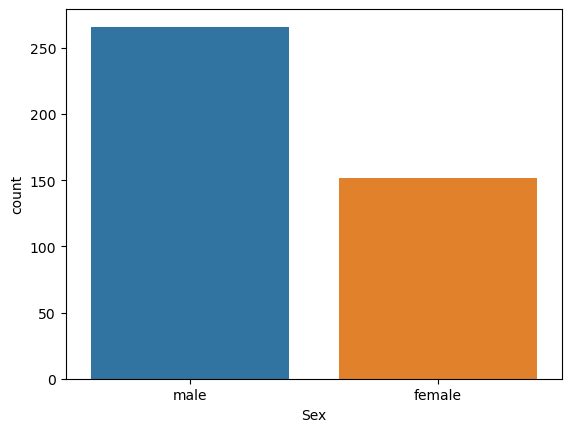

In [10]:
sns.countplot(x='Sex',data=df)

<Axes: xlabel='Sex', ylabel='count'>

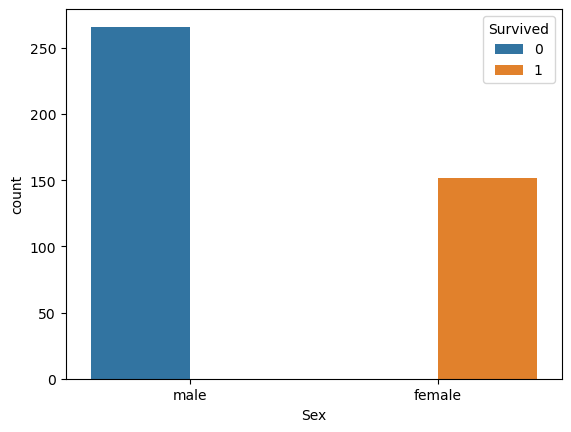

In [11]:
sns.countplot(x='Sex',data=df,hue='Survived')

<Axes: xlabel='Survived', ylabel='Age'>

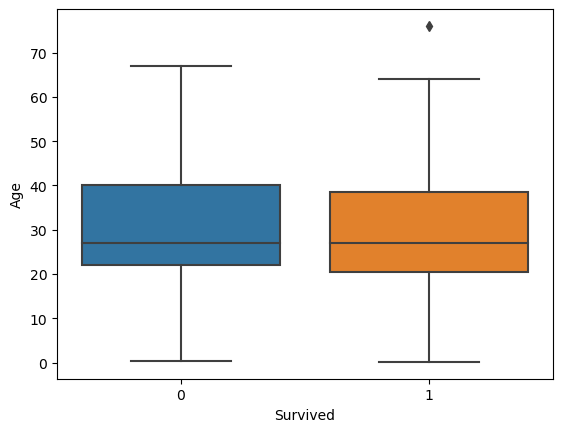

In [12]:
sns.boxplot(x='Survived',y='Age',data=df)

<Axes: xlabel='Sex', ylabel='Age'>

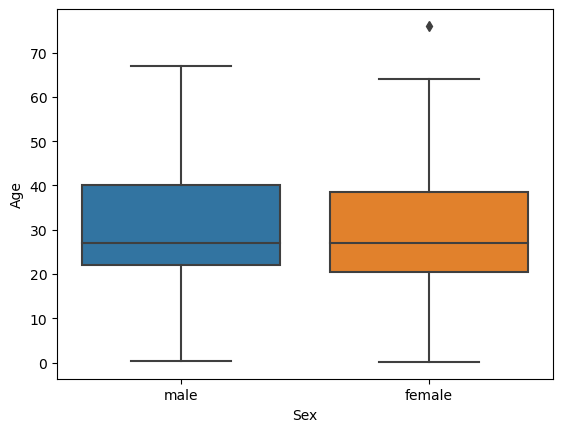

In [13]:
sns.boxplot(x='Sex',y='Age',data=df)

<Axes: xlabel='Embarked', ylabel='count'>

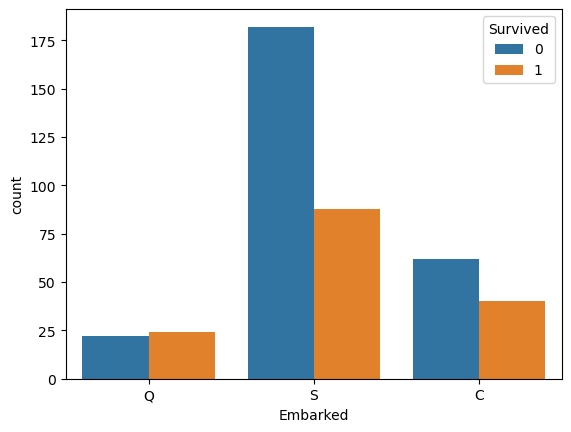

In [14]:
sns.countplot(x='Embarked',data=df,hue='Survived')

<Axes: xlabel='Survived', ylabel='Fare'>

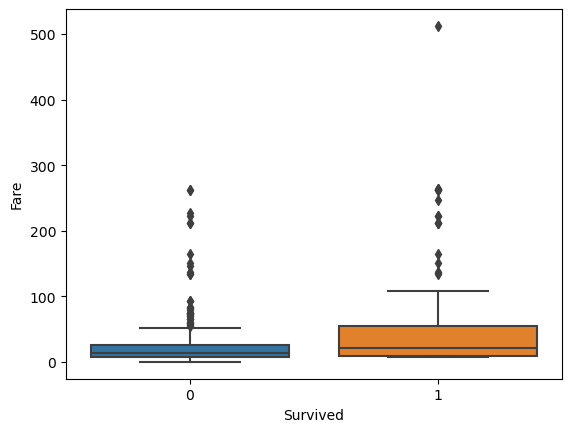

In [15]:
sns.boxplot(x='Survived',y='Fare',data=df)

<Axes: xlabel='Pclass', ylabel='count'>

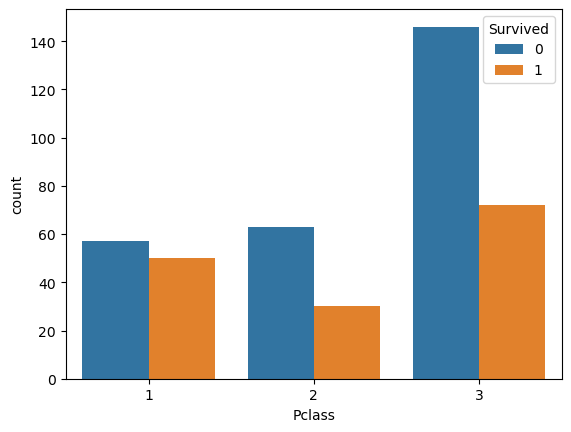

In [16]:
sns.countplot(x='Pclass',data=df,hue='Survived')

In [17]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age          86
SibSp         0
Parch         0
Fare          1
Cabin       327
Embarked      0
dtype: int64

In [18]:
age_dict  = dict(df.groupby('Pclass').Age.mean())

In [19]:
df.apply(lambda x : age_dict[x.Pclass] if str(x.Age)=='nan' else x.Age,axis=1)

0      34.500000
1      47.000000
2      62.000000
3      27.000000
4      22.000000
         ...    
413    24.027945
414    39.000000
415    38.500000
416    24.027945
417    24.027945
Length: 418, dtype: float64

In [20]:
df['Age'] = df.apply(lambda x : age_dict[x.Pclass] if str(x.Age)=='nan' else x.Age,axis=1)

In [21]:
df['Fare'].median()

14.4542

In [22]:
df['Fare'] = df['Fare'].fillna(14.45)

In [23]:
df['Cabin'].unique()

array([nan, 'B45', 'E31', 'B57 B59 B63 B66', 'B36', 'A21', 'C78', 'D34',
       'D19', 'A9', 'D15', 'C31', 'C23 C25 C27', 'F G63', 'B61', 'C53',
       'D43', 'C130', 'C132', 'C101', 'C55 C57', 'B71', 'C46', 'C116',
       'F', 'A29', 'G6', 'C6', 'C28', 'C51', 'E46', 'C54', 'C97', 'D22',
       'B10', 'F4', 'E45', 'E52', 'D30', 'B58 B60', 'E34', 'C62 C64',
       'A11', 'B11', 'C80', 'F33', 'C85', 'D37', 'C86', 'D21', 'C89',
       'F E46', 'A34', 'D', 'B26', 'C22 C26', 'B69', 'C32', 'B78',
       'F E57', 'F2', 'A18', 'C106', 'B51 B53 B55', 'D10 D12', 'E60',
       'E50', 'E39 E41', 'B52 B54 B56', 'C39', 'B24', 'D28', 'B41', 'C7',
       'D40', 'D38', 'C105'], dtype=object)

In [24]:
df.drop(['Cabin'],axis=1,inplace=True)

In [25]:
data = pd.get_dummies(df)

In [26]:
data.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,34.5,0,0,7.8292,0,1,0,1,0
1,1,3,47.0,1,0,7.0000,1,0,0,0,1
2,0,2,62.0,0,0,9.6875,0,1,0,1,0
3,0,3,27.0,0,0,8.6625,0,1,0,0,1
4,1,3,22.0,1,1,12.2875,1,0,0,0,1


In [27]:
x = data.drop(['Survived'],axis=1)
y = data.Survived

In [28]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=123)

In [29]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [30]:
trainProba = model.predict_proba(x_train)[:,1]
testProba = model.predict_proba(x_test)[:,1]

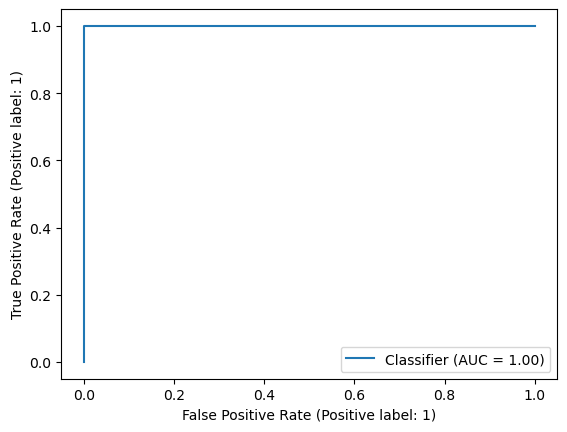

In [31]:
RocCurveDisplay.from_predictions(y_train,trainProba)

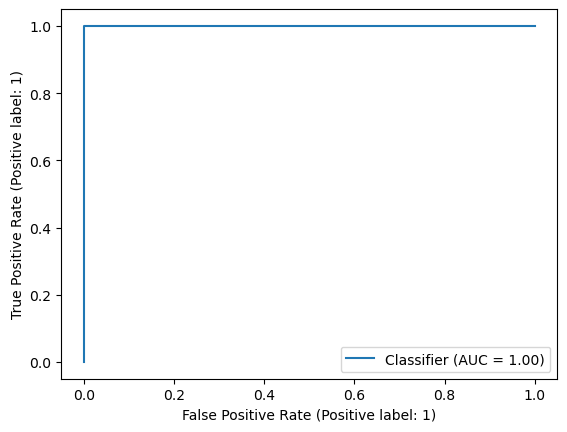

In [32]:
RocCurveDisplay.from_predictions(y_test,testProba)

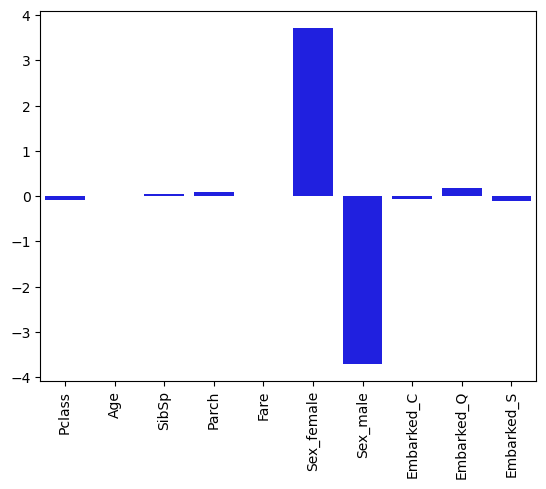

In [33]:
sns.barplot(x=x_train.columns, y= model.coef_[0],color='blue')
plt.xticks(rotation=90)
plt.show()

In [34]:
## Modelling without Sex

In [35]:
data = pd.get_dummies(df.drop('Sex',axis=1))

In [36]:
x = data.drop(['Survived',],axis=1)
y = data.Survived

In [37]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=123)

In [38]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [39]:
trainProba = model.predict_proba(x_train)[:,1]
testProba = model.predict_proba(x_test)[:,1]

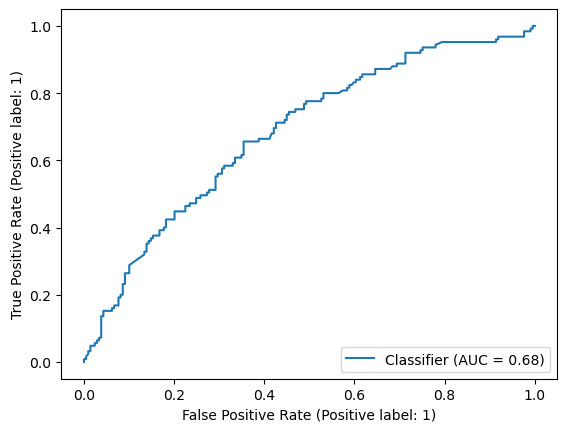

In [40]:
RocCurveDisplay.from_predictions(y_train,trainProba)

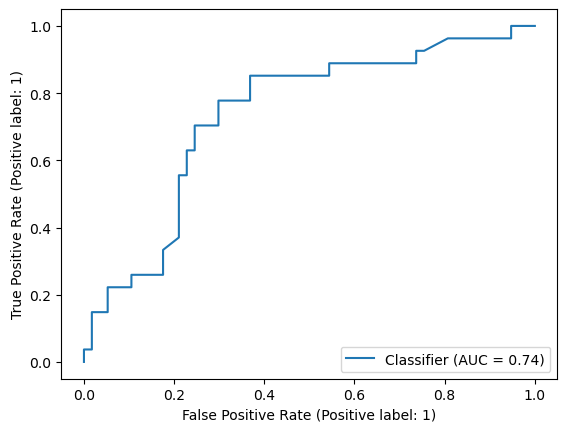

In [41]:
RocCurveDisplay.from_predictions(y_test,testProba)

In [42]:
p,r,th =precision_recall_curve(y_train,trainProba)

<Axes: >

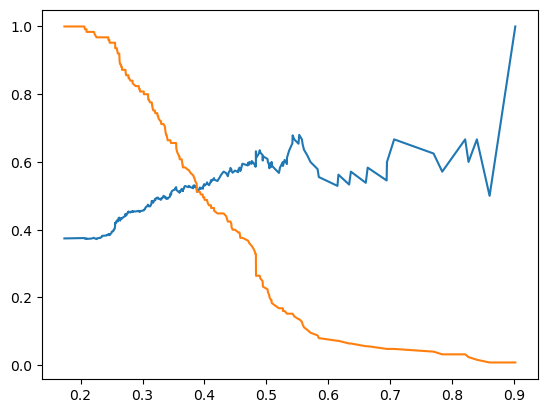

In [43]:
sns.lineplot(x=th,y=p[:-1])
sns.lineplot(x=th,y=r[:-1])

In [44]:
th = 0.4
trainPred = np.where(trainProba > th,1,0)
testPred = np.where(testProba > th,1,0)

In [45]:
print(classification_report(y_train,trainPred))

              precision    recall  f1-score   support

           0       0.71      0.74      0.72       209
           1       0.53      0.49      0.51       125

    accuracy                           0.65       334
   macro avg       0.62      0.61      0.62       334
weighted avg       0.64      0.65      0.64       334



In [46]:
print(classification_report(y_test,testPred))

              precision    recall  f1-score   support

           0       0.81      0.75      0.78        57
           1       0.55      0.63      0.59        27

    accuracy                           0.71        84
   macro avg       0.68      0.69      0.68        84
weighted avg       0.73      0.71      0.72        84



In [47]:
compute_class_weight(class_weight = 'balanced',classes = np.unique(y_train),y=y_train)

array([0.79904306, 1.336     ])

In [48]:

model = LogisticRegression(max_iter=1000,class_weight={0:0.79,1:1.33})
model.fit(x_train,y_train)


LogisticRegression(class_weight={0: 0.79, 1: 1.33}, max_iter=1000)

In [49]:
trainProba = model.predict_proba(x_train)[:,1]
testProba = model.predict_proba(x_test)[:,1]

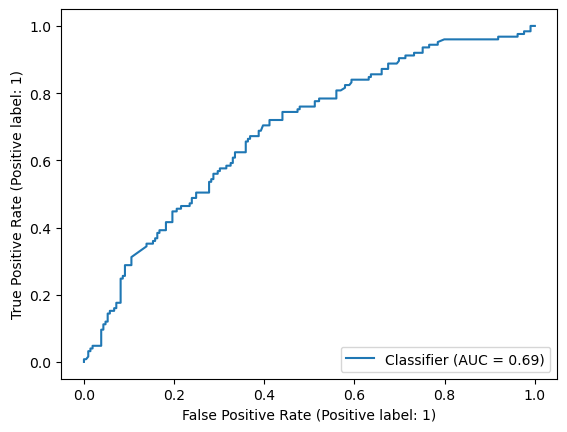

In [50]:
RocCurveDisplay.from_predictions(y_train,trainProba)